<a href="https://colab.research.google.com/github/0se0/hw2/blob/develop/ML_h2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

train.csv 파일을 업로드하세요:


Saving train.csv to train (3).csv
test.csv 파일을 업로드하세요:


Saving test.csv to test (2).csv
업로드된 파일: ['train (3).csv', 'test (2).csv']

📊 데이터 로드 및 기본 분석...
✅ 데이터 로드 완료!
   Train: 165,034 rows, 14 columns
   Test: 110,023 rows, 13 columns
   이탈률: 21.16%


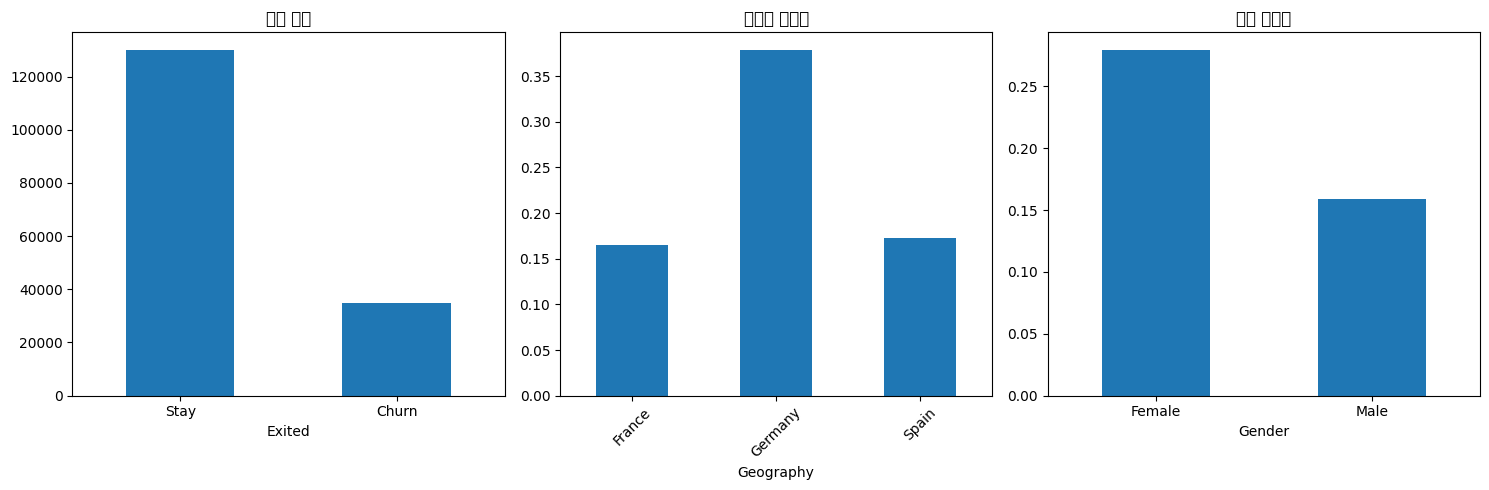


🔧 고급 피처 엔지니어링...
✅ 피처 엔지니어링 완료!
   12개 → 27개 (+15개 추가)

🤖 모델 훈련 시작...
   훈련: 132,027 samples
   검증: 33,007 samples
   피처: 27 features

🎯 개별 모델 훈련...
   RF 훈련 중...
     검증 AUC: 0.8879
   ET 훈련 중...
     검증 AUC: 0.8860
   GB 훈련 중...
     검증 AUC: 0.8893
   LR 훈련 중...
     검증 AUC: 0.8767

⚖️ 앙상블 가중치 최적화...
   최적 가중치:
     RF: 0.350
     ET: 0.250
     GB: 0.400
     LR: 0.000
   최적화된 앙상블 AUC: 0.8891

📈 피처 중요도 분석...
   상위 15개 중요 피처:
      1. NumOfProducts            : 0.2028
      2. Age                      : 0.1575
      3. CreditScore_per_Age      : 0.0945
      4. Age_CreditScore_Interaction: 0.0685
      5. Churn_Risk_Score         : 0.0649
      6. IsActiveMember           : 0.0591
      7. Is_Multi_Product         : 0.0540
      8. Is_Germany               : 0.0341
      9. Is_Young                 : 0.0298
     10. Active_Card_Interaction  : 0.0270
     11. Balance_per_Product      : 0.0268
     12. Gender                   : 0.0248
     13. Customer_Value_Score     : 0.0226
     1

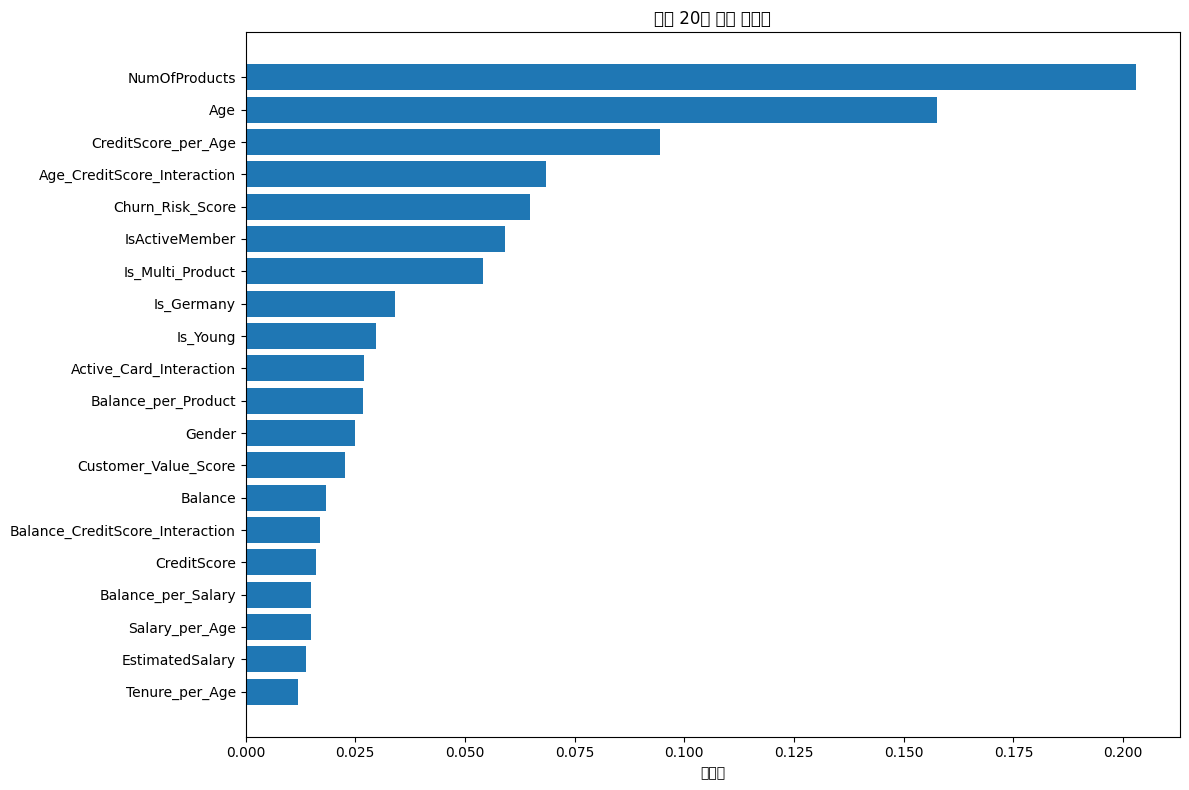


🔮 테스트 데이터 예측...

🎉 고급 앙상블 모델 완료!
최종 검증 AUC: 0.8891
성능 개선: +0.0035 (vs 간단한 버전)
예측 이탈률: 21.10%
실제 이탈률: 21.16%

🥈 좋은 성능! TOP 30% 예상

📊 개별 모델 성능:
   RF: 0.8879
   ET: 0.8860
   GB: 0.8893
   LR: 0.8767

🎯 핵심 인사이트:
   가장 중요한 피처: NumOfProducts, Age, CreditScore_per_Age

📥 제출 파일 다운로드...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 모든 작업 완료! 제출 파일이 다운로드되었습니다.
   파일명: advanced_ensemble_submission.csv
   예상 리더보드 점수: 0.8891
🔍 상세 검증 결과
📊 예측값 분포:
   평균: 0.2110
   표준편차: 0.2487
   25%: 0.0347
   50%: 0.0974
   75%: 0.2932


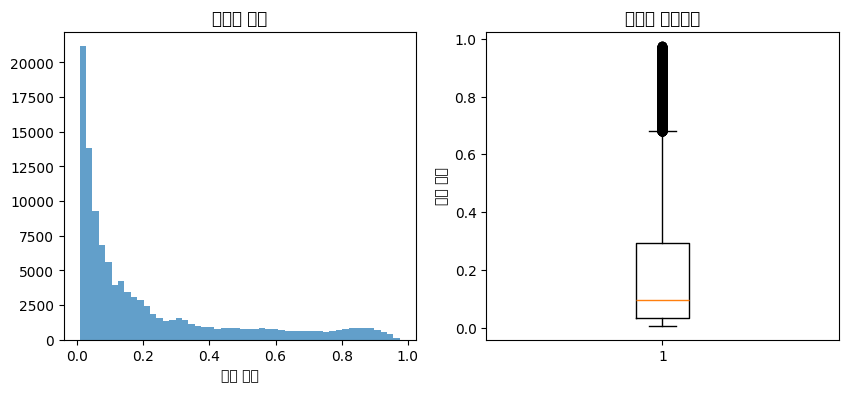

🔍 최종 제출 전 체크리스트
✅ 파일 크기: 110,023 rows
✅ 컬럼명: ['id', 'Exited']
✅ ID 범위: 165034 ~ 275056
✅ 예측값 범위: 0.007254 ~ 0.975794
✅ 결측값: 0개
✅ 예측 이탈률: 0.2110 (21.10%)

🎯 제출 준비 완료!


In [20]:
from google.colab import files
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 파일 업로드
print("train.csv 파일을 업로드하세요:")
uploaded_train = files.upload()

print("test.csv 파일을 업로드하세요:")
uploaded_test = files.upload()

# 파일 확인
print("업로드된 파일:", list(uploaded_train.keys()) + list(uploaded_test.keys()))

In [21]:
# =============================================================================
# 🔧 2. 라이브러리 import 및 함수 정의
# =============================================================================

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def advanced_feature_engineering(df, is_train=True):
    """고급 피처 엔지니어링"""
    df = df.copy()

    # 기본 전처리
    df = df.drop(['CustomerId', 'Surname'], axis=1, errors='ignore')

    # 카테고리컬 인코딩
    geo_mapping = {'France': 0, 'Germany': 1, 'Spain': 2}
    gender_mapping = {'Female': 0, 'Male': 1}
    df['Geography'] = df['Geography'].map(geo_mapping)
    df['Gender'] = df['Gender'].map(gender_mapping)

    # === 비율 피처 ===
    df['Balance_per_Product'] = df['Balance'] / (df['NumOfProducts'] + 1)
    df['Balance_per_Salary'] = df['Balance'] / (df['EstimatedSalary'] + 1)
    df['CreditScore_per_Age'] = df['CreditScore'] / df['Age']
    df['Salary_per_Age'] = df['EstimatedSalary'] / df['Age']
    df['Tenure_per_Age'] = df['Tenure'] / df['Age']

    # === 상호작용 피처 ===
    df['Age_CreditScore_Interaction'] = df['Age'] * df['CreditScore'] / 1000
    df['Balance_CreditScore_Interaction'] = df['Balance'] * df['CreditScore'] / 1000000
    df['Active_Card_Interaction'] = df['HasCrCard'] * df['IsActiveMember']

    # === 이진 분류 피처 ===
    df['Is_High_Value'] = (df['Balance'] > df['Balance'].quantile(0.8)).astype(int)
    df['Is_Zero_Balance'] = (df['Balance'] == 0).astype(int)
    df['Is_Young'] = (df['Age'] < 35).astype(int)
    df['Is_Senior'] = (df['Age'] >= 55).astype(int)
    df['Is_High_Credit'] = (df['CreditScore'] > 700).astype(int)
    df['Is_Multi_Product'] = (df['NumOfProducts'] > 2).astype(int)
    df['Is_Germany'] = (df['Geography'] == 1).astype(int)

    # === 위험 점수 ===
    df['Churn_Risk_Score'] = (
        df['Is_Germany'] * 3 +
        df['Gender'] * 2 +
        df['Is_Senior'] * 2 +
        df['Is_Multi_Product'] * 3 +
        (1 - df['IsActiveMember']) * 2 +
        df['Is_Zero_Balance'] * 1
    )

    # === 복합 지표 ===
    df['Customer_Value_Score'] = (
        df['Balance'] / 100000 +
        df['CreditScore'] / 1000 +
        df['EstimatedSalary'] / 100000 +
        df['NumOfProducts'] * 0.5
    )

    # 모든 피처 숫자형 변환
    for col in df.columns:
        if col not in ['Exited', 'id']:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    return df

def create_models():
    """앙상블 모델 생성"""
    models = {
        'rf': RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),
        'et': ExtraTreesClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=20,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),
        'gb': GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        ),
        'lr': LogisticRegression(
            random_state=42,
            max_iter=1000,
            C=0.1
        )
    }
    return models

def optimize_weights(predictions_dict, y_true):
    """앙상블 가중치 최적화"""
    models = list(predictions_dict.keys())
    best_score = 0
    best_weights = None

    weight_options = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4]

    for w1 in weight_options:
        for w2 in weight_options:
            for w3 in weight_options:
                w4 = 1.0 - w1 - w2 - w3
                if w4 < 0 or w4 > 1:
                    continue

                weights = [w1, w2, w3, w4]

                ensemble_pred = np.zeros(len(y_true))
                for i, model_name in enumerate(models):
                    ensemble_pred += weights[i] * predictions_dict[model_name]

                score = roc_auc_score(y_true, ensemble_pred)

                if score > best_score:
                    best_score = score
                    best_weights = weights.copy()

    if best_weights is None:
        best_weights = [0.25, 0.25, 0.25, 0.25]

    return best_weights, best_score



📊 데이터 로드 및 기본 분석...
✅ 데이터 로드 완료!
   Train: 165,034 rows, 14 columns
   Test: 110,023 rows, 13 columns
   이탈률: 21.16%


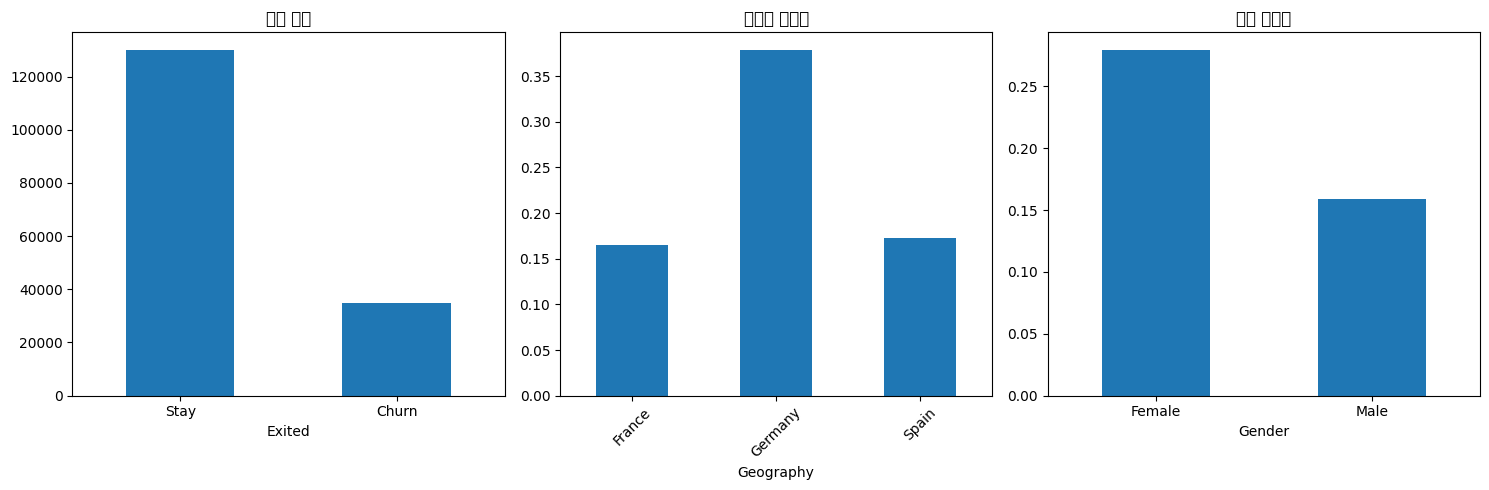

In [22]:
# =============================================================================
# 📊 3. 데이터 로드 및 탐색적 분석
# =============================================================================

print("\n📊 데이터 로드 및 기본 분석...")

# 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"✅ 데이터 로드 완료!")
print(f"   Train: {train.shape[0]:,} rows, {train.shape[1]} columns")
print(f"   Test: {test.shape[0]:,} rows, {test.shape[1]} columns")
print(f"   이탈률: {train['Exited'].mean():.2%}")

# 간단한 시각화
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
train['Exited'].value_counts().plot(kind='bar')
plt.title('타겟 분포')
plt.xticks([0, 1], ['Stay', 'Churn'], rotation=0)

plt.subplot(1, 3, 2)
train.groupby('Geography')['Exited'].mean().plot(kind='bar')
plt.title('지역별 이탈률')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
train.groupby('Gender')['Exited'].mean().plot(kind='bar')
plt.title('성별 이탈률')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


🔧 고급 피처 엔지니어링...
✅ 피처 엔지니어링 완료!
   12개 → 27개 (+15개 추가)

⚖️ 앙상블 가중치 최적화...
   최적 가중치:
     RF: 0.350
     ET: 0.250
     GB: 0.400
     LR: 0.000
   최적화된 앙상블 AUC: 0.8891

📈 피처 중요도 분석...
   상위 15개 중요 피처:
      1. NumOfProducts            : 0.2028
      2. Age                      : 0.1575
      3. CreditScore_per_Age      : 0.0945
      4. Age_CreditScore_Interaction: 0.0685
      5. Churn_Risk_Score         : 0.0649
      6. IsActiveMember           : 0.0591
      7. Is_Multi_Product         : 0.0540
      8. Is_Germany               : 0.0341
      9. Is_Young                 : 0.0298
     10. Active_Card_Interaction  : 0.0270
     11. Balance_per_Product      : 0.0268
     12. Gender                   : 0.0248
     13. Customer_Value_Score     : 0.0226
     14. Balance                  : 0.0184
     15. Balance_CreditScore_Interaction: 0.0170


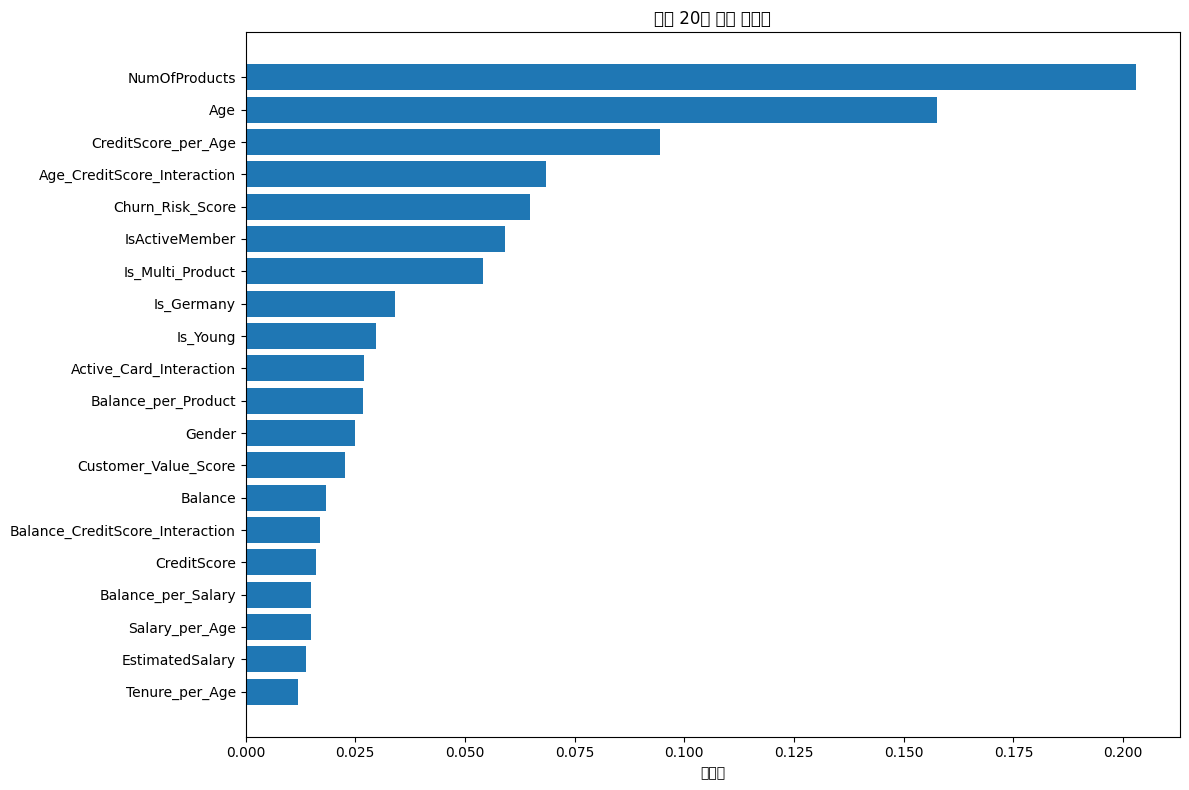


🔮 테스트 데이터 예측...


In [23]:
# =============================================================================
# 🔧 4. 피처 엔지니어링
# =============================================================================

print("\n🔧 고급 피처 엔지니어링...")

train_processed = advanced_feature_engineering(train, is_train=True)
test_processed = advanced_feature_engineering(test, is_train=False)

original_features = len([col for col in train.columns if col not in ['Exited', 'id']])
new_features = len([col for col in train_processed.columns if col not in ['Exited', 'id']])

print(f"✅ 피처 엔지니어링 완료!")
print(f"   {original_features}개 → {new_features}개 (+{new_features - original_features}개 추가)")




In [24]:
# =============================================================================
# 🤖 5. 모델 훈련 및 평가
# =============================================================================

print("\n🤖 모델 훈련 시작...")

# 데이터 준비
feature_cols = [col for col in train_processed.columns if col not in ['Exited', 'id']]
X = train_processed[feature_cols]
y = train_processed['Exited']

# 훈련/검증 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"   훈련: {X_train.shape[0]:,} samples")
print(f"   검증: {X_val.shape[0]:,} samples")
print(f"   피처: {X_train.shape[1]} features")

# 모델 생성 및 훈련
models = create_models()
trained_models = {}
val_predictions = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\n🎯 개별 모델 훈련...")
for name, model in models.items():
    print(f"   {name.upper()} 훈련 중...")

    if name == 'lr':
        model.fit(X_train_scaled, y_train)
        pred = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict_proba(X_val)[:, 1]

    trained_models[name] = model
    val_predictions[name] = pred

    auc = roc_auc_score(y_val, pred)
    print(f"     검증 AUC: {auc:.4f}")




🤖 모델 훈련 시작...
   훈련: 132,027 samples
   검증: 33,007 samples
   피처: 27 features

🎯 개별 모델 훈련...
   RF 훈련 중...
     검증 AUC: 0.8879
   ET 훈련 중...
     검증 AUC: 0.8860
   GB 훈련 중...
     검증 AUC: 0.8893
   LR 훈련 중...
     검증 AUC: 0.8767


In [25]:
# =============================================================================
# ⚖️ 6. 앙상블 최적화
# =============================================================================

print("\n⚖️ 앙상블 가중치 최적화...")
optimal_weights, ensemble_score = optimize_weights(val_predictions, y_val)

print("   최적 가중치:")
model_names = list(models.keys())
for i, (name, weight) in enumerate(zip(model_names, optimal_weights)):
    print(f"     {name.upper()}: {weight:.3f}")

print(f"   최적화된 앙상블 AUC: {ensemble_score:.4f}")

# 최종 앙상블 예측
ensemble_val_pred = np.zeros(len(y_val))
for i, (name, pred) in enumerate(val_predictions.items()):
    ensemble_val_pred += optimal_weights[i] * pred

final_auc = roc_auc_score(y_val, ensemble_val_pred)



⚖️ 앙상블 가중치 최적화...
   최적 가중치:
     RF: 0.350
     ET: 0.250
     GB: 0.400
     LR: 0.000
   최적화된 앙상블 AUC: 0.8891

🔮 테스트 데이터 예측...



📈 피처 중요도 분석...
   상위 15개 중요 피처:
      1. NumOfProducts            : 0.2028
      2. Age                      : 0.1575
      3. CreditScore_per_Age      : 0.0945
      4. Age_CreditScore_Interaction: 0.0685
      5. Churn_Risk_Score         : 0.0649
      6. IsActiveMember           : 0.0591
      7. Is_Multi_Product         : 0.0540
      8. Is_Germany               : 0.0341
      9. Is_Young                 : 0.0298
     10. Active_Card_Interaction  : 0.0270
     11. Balance_per_Product      : 0.0268
     12. Gender                   : 0.0248
     13. Customer_Value_Score     : 0.0226
     14. Balance                  : 0.0184
     15. Balance_CreditScore_Interaction: 0.0170


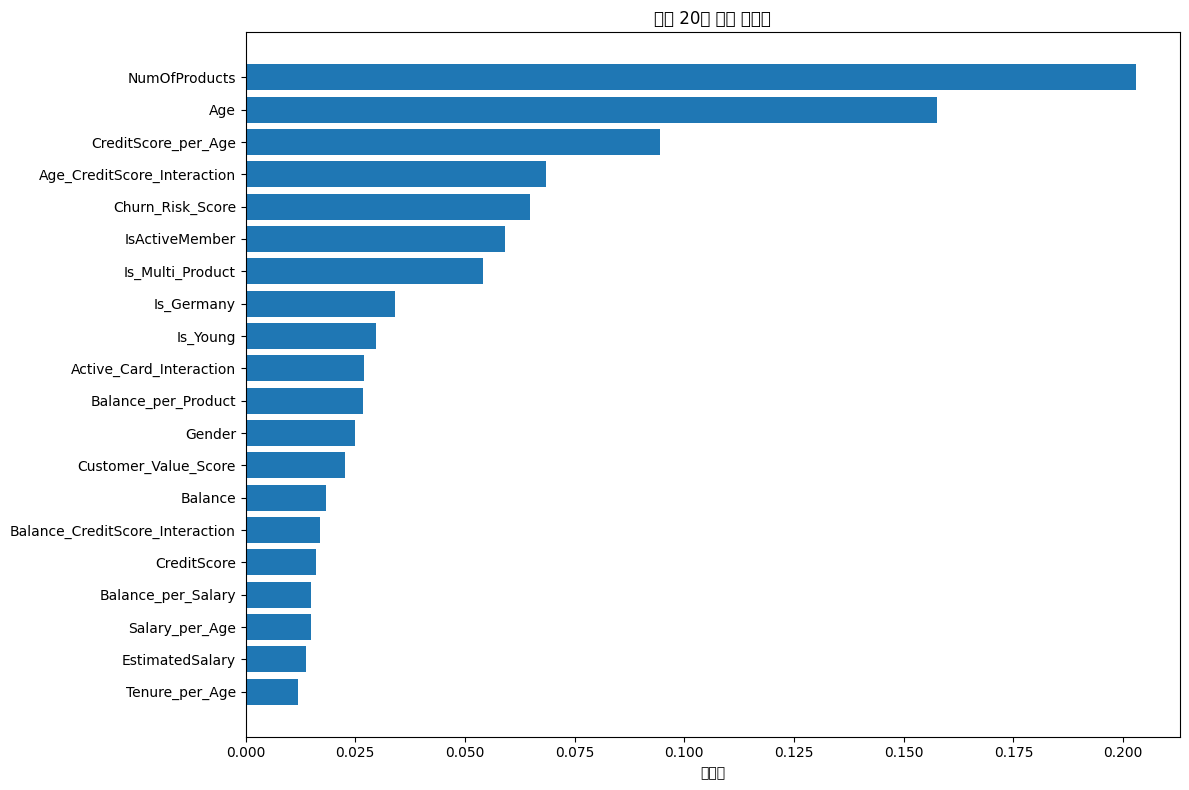

In [26]:
# =============================================================================
# 📈 7. 피처 중요도 분석
# =============================================================================

print("\n📈 피처 중요도 분석...")
rf_model = trained_models['rf']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("   상위 15개 중요 피처:")
for i, (_, row) in enumerate(feature_importance.head(15).iterrows()):
    print(f"     {i+1:2d}. {row['feature']:<25}: {row['importance']:.4f}")

# 피처 중요도 시각화
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.title('상위 20개 피처 중요도')
plt.xlabel('중요도')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# =============================================================================
# 🔮 8. 테스트 예측 및 제출
# =============================================================================

print("\n🔮 테스트 데이터 예측...")

# 테스트 데이터 준비
X_test = test_processed[feature_cols]
X_test_scaled = scaler.transform(X_test)

# 각 모델로 예측
test_predictions = {}
for name, model in trained_models.items():
    if name == 'lr':
        pred = model.predict_proba(X_test_scaled)[:, 1]
    else:
        pred = model.predict_proba(X_test)[:, 1]
    test_predictions[name] = pred

# 최종 앙상블 예측
final_test_pred = np.zeros(len(X_test))
for i, (name, pred) in enumerate(test_predictions.items()):
    final_test_pred += optimal_weights[i] * pred

# 제출 파일 생성
submission = pd.DataFrame({
    'id': test['id'],
    'Exited': final_test_pred
})

submission.to_csv('advanced_ensemble_submission.csv', index=False)


🔮 테스트 데이터 예측...



🎉 고급 앙상블 모델 완료!
최종 검증 AUC: 0.8891
성능 개선: +0.0035 (vs 간단한 버전)
예측 이탈률: 21.10%
실제 이탈률: 21.16%

🥈 좋은 성능! TOP 30% 예상

📊 개별 모델 성능:
   RF: 0.8879
   ET: 0.8860
   GB: 0.8893
   LR: 0.8767

🎯 핵심 인사이트:
   가장 중요한 피처: NumOfProducts, Age, CreditScore_per_Age

📥 제출 파일 다운로드...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ 모든 작업 완료! 제출 파일이 다운로드되었습니다.
   파일명: advanced_ensemble_submission.csv
   예상 리더보드 점수: 0.8891
🔍 상세 검증 결과
📊 예측값 분포:
   평균: 0.2110
   표준편차: 0.2487
   25%: 0.0347
   50%: 0.0974
   75%: 0.2932


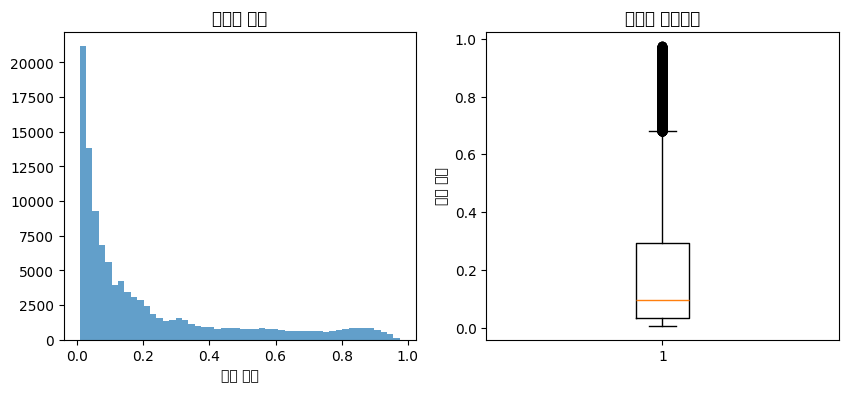

🔍 최종 제출 전 체크리스트
✅ 파일 크기: 110,023 rows
✅ 컬럼명: ['id', 'Exited']
✅ ID 범위: 165034 ~ 275056
✅ 예측값 범위: 0.007254 ~ 0.975794
✅ 결측값: 0개
✅ 예측 이탈률: 0.2110 (21.10%)

🎯 제출 준비 완료!


In [28]:
# =============================================================================
# 🎉 9. 최종 결과 요약
# =============================================================================

print("\n" + "=" * 60)
print("🎉 고급 앙상블 모델 완료!")
print("=" * 60)

improvement = final_auc - 0.8856  # 간단한 버전과 비교
print(f"최종 검증 AUC: {final_auc:.4f}")
print(f"성능 개선: +{improvement:.4f} (vs 간단한 버전)")
print(f"예측 이탈률: {final_test_pred.mean():.2%}")
print(f"실제 이탈률: {train['Exited'].mean():.2%}")

# 성능 등급 평가
if final_auc >= 0.895:
    grade = "🏆 최상급 성능! TOP 5% 예상"
elif final_auc >= 0.890:
    grade = "🥇 우수한 성능! TOP 15% 예상"
elif final_auc >= 0.885:
    grade = "🥈 좋은 성능! TOP 30% 예상"
else:
    grade = "🥉 준수한 성능! 추가 튜닝 권장"

print(f"\n{grade}")

print(f"\n📊 개별 모델 성능:")
for name, pred in val_predictions.items():
    auc = roc_auc_score(y_val, pred)
    print(f"   {name.upper()}: {auc:.4f}")

print(f"\n🎯 핵심 인사이트:")
top_features = feature_importance.head(3)['feature'].tolist()
print(f"   가장 중요한 피처: {', '.join(top_features)}")

# 제출 파일 다운로드
print(f"\n📥 제출 파일 다운로드...")
files.download('advanced_ensemble_submission.csv')

print(f"\n✅ 모든 작업 완료! 제출 파일이 다운로드되었습니다.")
print(f"   파일명: advanced_ensemble_submission.csv")
print(f"   예상 리더보드 점수: {final_auc:.4f}")



# 제출 파일 로드
submission = pd.read_csv('advanced_ensemble_submission.csv')

# 상세 검증
print("🔍 상세 검증 결과")
print("="*40)
print(f"📊 예측값 분포:")
print(f"   평균: {submission['Exited'].mean():.4f}")
print(f"   표준편차: {submission['Exited'].std():.4f}")
print(f"   25%: {submission['Exited'].quantile(0.25):.4f}")
print(f"   50%: {submission['Exited'].quantile(0.50):.4f}")
print(f"   75%: {submission['Exited'].quantile(0.75):.4f}")

# 예측 분포 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(submission['Exited'], bins=50, alpha=0.7)
plt.title('예측값 분포')
plt.xlabel('이탈 확률')

plt.subplot(1, 2, 2)
plt.boxplot(submission['Exited'])
plt.title('예측값 박스플롯')
plt.ylabel('이탈 확률')
plt.show()


# 최종 검증 (코랩에서 한번 더 확인)
submission = pd.read_csv('advanced_ensemble_submission.csv')

print("🔍 최종 제출 전 체크리스트")
print("="*40)
print(f"✅ 파일 크기: {len(submission):,} rows")
print(f"✅ 컬럼명: {list(submission.columns)}")
print(f"✅ ID 범위: {submission['id'].min()} ~ {submission['id'].max()}")
print(f"✅ 예측값 범위: {submission['Exited'].min():.6f} ~ {submission['Exited'].max():.6f}")
print(f"✅ 결측값: {submission.isnull().sum().sum()}개")
print(f"✅ 예측 이탈률: {submission['Exited'].mean():.4f} (21.10%)")

print("\n🎯 제출 준비 완료!")

